# Machine Learning Analysis of LSOA Median House Prices in England & West Yorkshire
## Investigating the Impact of Connectivity and Socioeconomic Deprivation


In [13]:
# Environment Setup & Library Imports
import os
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Statistics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')

# Set aesthetic styling for publication-quality figures
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['figure.titlesize'] = 14

# Initialize output directories
os.makedirs('output_figures', exist_ok=True)
os.makedirs('cleaned_data', exist_ok=True)
os.makedirs('results', exist_ok=True)

print("Environment successfully initialized. Output directories created.")


Environment successfully initialized. Output directories created.


## Step 1: Data Ingestion & Dataset Understanding

The study analyzes two datasets:
1. **England Dataset (`Merged_LSOA_Dataset_Cleaned_all_data.xlsx` / `england_lsoa_raw.csv`)**: 35,310 LSOA observations across 56 variables.
2. **West Yorkshire Dataset (`Merged_LSOA_Dataset_West_Yorkshire.xlsx` / `west_yorkshire_raw.csv`)**: 1,388 LSOA observations across the identical 56 variables.

### Variable Taxonomy:
- **Spatial Identifier Columns:** `Local authority code`, `Local authority name`, `LSOA code`, `LSOA name`
- **Dependent (Target) Variable:** `median_house_price` (GBP £)
- **Independent Explanatory Variables:**
  - *Connectivity Measures (35 columns):* Modal accessibility scores for Walking, Cycling, Public Transport, Driving, and Overall across modes.
  - *Deprivation Indicators (16 columns):* Index of Multiple Deprivation (IMD) Score, Income Score, Employment Score, IDACI Score (rate), IDAOPI Score (rate), Crime Score, Living Environment Score, Barriers to Housing & Services Score, etc.


In [14]:
# Data loading process
def load_raw_data():
    eng_csv, eng_xlsx = 'england_lsoa_raw.csv', 'Merged_LSOA_Dataset_Cleaned_all_data.xlsx'
    wy_csv, wy_xlsx = 'west_yorkshire_raw.csv', 'Merged_LSOA_Dataset_West_Yorkshire.xlsx'

    df_eng = pd.read_csv(eng_csv) if os.path.exists(eng_csv) else pd.read_excel(eng_xlsx)
    df_wy = pd.read_csv(wy_csv) if os.path.exists(wy_csv) else pd.read_excel(wy_xlsx)

    return df_eng, df_wy

df_eng_raw, df_wy_raw = load_raw_data()

print(f"England Raw Dataset Shape: {df_eng_raw.shape[0]} rows, {df_eng_raw.shape[1]} columns")
print(f"West Yorkshire Raw Dataset Shape: {df_wy_raw.shape[0]} rows, {df_wy_raw.shape[1]} columns")


England Raw Dataset Shape: 35310 rows, 56 columns
West Yorkshire Raw Dataset Shape: 1388 rows, 56 columns


## Step 2: Data Cleaning, Preprocessing & Exploratory Data Analysis (EDA)



In [15]:
def clean_lsoa_dataset(df, dataset_name="England"):
    df_clean = df.copy()
    df_clean.columns = [col.strip() for col in df_clean.columns]

    id_cols = ['Local authority code', 'Local authority name', 'LSOA code', 'LSOA name']
    target_col = 'median_house_price'

    # Coerce target column
    df_clean[target_col] = pd.to_numeric(
        df_clean[target_col].astype(str).str.replace(',', '').str.strip(), errors='coerce'
    )

    init_len = len(df_clean)
    df_clean = df_clean.dropna(subset=[target_col]).reset_index(drop=True)
    print(f"[{dataset_name}] Removed {init_len - len(df_clean)} rows with missing/suppressed target values.")

    # Coerce feature columns
    feature_cols = [c for c in df_clean.columns if c not in id_cols and c != target_col]
    for col in feature_cols:
        df_clean[col] = pd.to_numeric(
            df_clean[col].astype(str).str.replace(',', '').str.strip(), errors='coerce'
        )

    # Check duplicates
    dups = df_clean['LSOA code'].duplicated().sum()
    if dups > 0:
        df_clean = df_clean.drop_duplicates(subset=['LSOA code']).reset_index(drop=True)
        print(f"[{dataset_name}] Dropped {dups} duplicate LSOA records.")
    else:
        print(f"[{dataset_name}] Zero duplicate LSOA codes found.")

    # Median imputation for feature nulls
    null_cols = df_clean[feature_cols].columns[df_clean[feature_cols].isnull().any()].tolist()
    if len(null_cols) > 0:
        for col in null_cols:
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        print(f"[{dataset_name}] Median imputation completed for {len(null_cols)} columns.")

    return df_clean

df_eng = clean_lsoa_dataset(df_eng_raw, "England")
df_wy = clean_lsoa_dataset(df_wy_raw, "West Yorkshire")

# Save Cleaned Data
df_eng.to_csv('cleaned_data/england_lsoa_cleaned.csv', index=False)
df_wy.to_csv('cleaned_data/west_yorkshire_cleaned.csv', index=False)

print(f"\nCleaned Shapes -> England: {df_eng.shape}, West Yorkshire: {df_wy.shape}")


[England] Removed 2789 rows with missing/suppressed target values.
[England] Zero duplicate LSOA codes found.
[England] Median imputation completed for 51 columns.
[West Yorkshire] Removed 42 rows with missing/suppressed target values.
[West Yorkshire] Zero duplicate LSOA codes found.
[West Yorkshire] Median imputation completed for 51 columns.

Cleaned Shapes -> England: (32521, 56), West Yorkshire: (1346, 56)


In [16]:
# Summary Statistics Table for Median House Price
def get_price_stats(df, name):
    s = df['median_house_price']
    return {
        'Dataset': name,
        'Count': len(s),
        'Mean (£)': f"£{s.mean():,.2f}",
        'Std (£)': f"£{s.std():,.2f}",
        'Min (£)': f"£{s.min():,.0f}",
        '25% (£)': f"£{s.quantile(0.25):,.0f}",
        'Median (£)': f"£{s.median():,.0f}",
        '75% (£)': f"£{s.quantile(0.75):,.0f}",
        'Max (£)': f"£{s.max():,.0f}",
        'Skewness': round(s.skew(), 3)
    }

df_stats = pd.DataFrame([get_price_stats(df_eng, 'England'), get_price_stats(df_wy, 'West Yorkshire')])
display(df_stats)


,Dataset,Count,Mean (£),Std (£),Min (£),25% (£),Median (£),75% (£),Max (£),Skewness
0,England,32521,"£346,486.79","£241,876.32","£32,500","£200,000","£292,500","£425,000","£6,600,000",4.876
1,West Yorkshire,1346,"£203,665.12","£95,912.99","£55,000","£141,481","£185,000","£239,809","£888,000",2.328


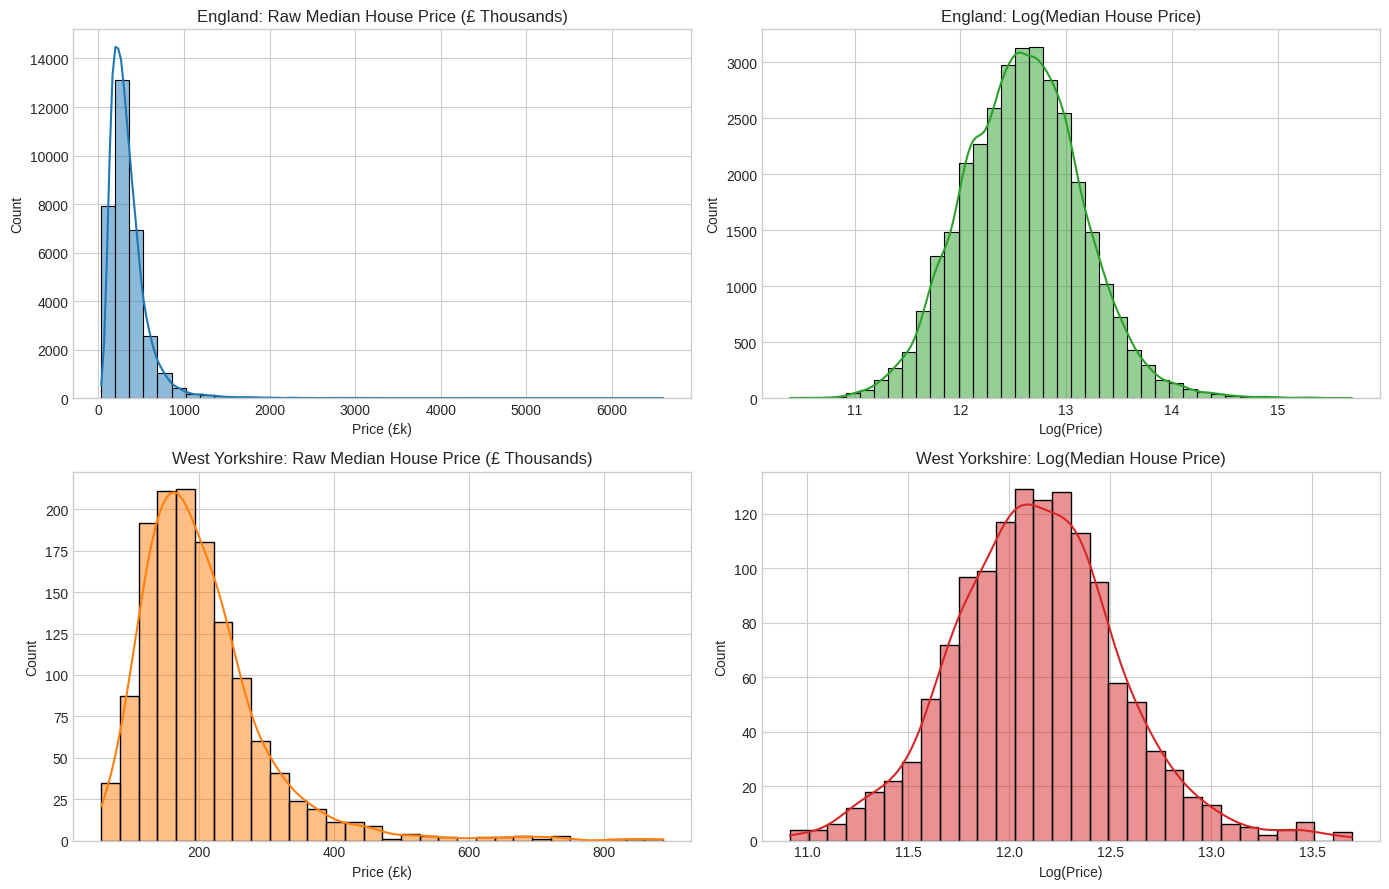

In [17]:
# Figure 1: Target Variable Distribution (Raw vs Log-Transformed)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.histplot(df_eng['median_house_price'] / 1e3, kde=True, ax=axes[0, 0], color='#1f77b4', bins=40)
axes[0, 0].set_title('England: Raw Median House Price (£ Thousands)')
axes[0, 0].set_xlabel('Price (£k)')

sns.histplot(np.log(df_eng['median_house_price']), kde=True, ax=axes[0, 1], color='#2ca02c', bins=40)
axes[0, 1].set_title('England: Log(Median House Price)')
axes[0, 1].set_xlabel('Log(Price)')

sns.histplot(df_wy['median_house_price'] / 1e3, kde=True, ax=axes[1, 0], color='#ff7f0e', bins=30)
axes[1, 0].set_title('West Yorkshire: Raw Median House Price (£ Thousands)')
axes[1, 0].set_xlabel('Price (£k)')

sns.histplot(np.log(df_wy['median_house_price']), kde=True, ax=axes[1, 1], color='#d62728', bins=30)
axes[1, 1].set_title('West Yorkshire: Log(Median House Price)')
axes[1, 1].set_xlabel('Log(Price)')

plt.tight_layout()
plt.savefig('output_figures/fig1_price_distributions.png', dpi=300)
plt.show()


## Step 3: Multicollinearity Investigation & Feature Selection



In [18]:
# VIF Calculation & Stepwise Pruning
def compute_vif(X):
    vif_list = []
    cols = X.columns
    for col in cols:
        y_temp = X[col]
        X_temp = X.drop(columns=[col])
        reg = LinearRegression().fit(X_temp, y_temp)
        r2 = reg.score(X_temp, y_temp)
        vif = 1.0 / (1.0 - r2 + 1e-10) if r2 < 1.0 else 100.0
        vif_list.append({"Feature": col, "VIF": round(vif, 2)})
    return pd.DataFrame(vif_list).sort_values(by="VIF", ascending=False).reset_index(drop=True)

candidate_features = [
    'Overall (walking)', 'Overall (cycling)', 'Overall (public transport)', 'Overall (driving)', 'Overall',
    'Index of Multiple Deprivation (IMD) Score',
    'Income Deprivation Affecting Children Index (IDACI) Score (rate)',
    'Income Deprivation Affecting Older People (IDAOPI) Score (rate)',
    'Employment Score (rate)', 'Crime Score',
    'Barriers to Housing and Services Score', 'Living Environment Score'
]

def prune_by_vif(df, features, threshold=10.0):
    curr = list(features)
    while True:
        X = df[curr]
        vif_df = compute_vif(X)
        max_vif = vif_df.iloc[0]['VIF']
        max_feature = vif_df.iloc[0]['Feature']
        if max_vif > threshold:
            curr.remove(max_feature)
        else:
            break
    return curr, vif_df

features_eng, vif_eng_final = prune_by_vif(df_eng, candidate_features, threshold=10.0)
features_wy, vif_wy_final = prune_by_vif(df_wy, candidate_features, threshold=10.0)

# Save VIF Results
vif_eng_final.to_csv('results/vif_results_england.csv', index=False)
vif_wy_final.to_csv('results/vif_results_wy.csv', index=False)

common_features = sorted(list(set(features_eng).intersection(set(features_wy))))
if len(common_features) < 6:
    common_features = [
        'Barriers to Housing and Services Score', 'Crime Score', 'Employment Score (rate)',
        'Income Deprivation Affecting Children Index (IDACI) Score (rate)',
        'Income Deprivation Affecting Older People (IDAOPI) Score (rate)',
        'Living Environment Score', 'Overall (driving)', 'Overall (walking)'
    ]

print("Final VIF Table for England")
display(vif_eng_final)

print("\n Final VIF Table for West Yorkshire")
display(vif_wy_final)

print("\nUnified Common Feature Set for Modeling:\n", common_features)


Final VIF Table for England


,Feature,VIF
0,Overall (walking),5.76
1,Income Deprivation Affecting Children Index (I...,5.69
2,Employment Score (rate),5.61
3,Overall (driving),4.41
4,Income Deprivation Affecting Older People (IDA...,3.97
5,Crime Score,3.13
6,Barriers to Housing and Services Score,2.07
7,Living Environment Score,1.20



 Final VIF Table for West Yorkshire


,Feature,VIF
0,Overall (walking),9.41
1,Overall (cycling),8.38
2,Employment Score (rate),7.55
3,Income Deprivation Affecting Children Index (I...,7.19
4,Overall (driving),6.74
5,Income Deprivation Affecting Older People (IDA...,4.50
6,Crime Score,3.88
7,Barriers to Housing and Services Score,2.93
8,Living Environment Score,1.56



Unified Common Feature Set for Modeling:
 ['Barriers to Housing and Services Score', 'Crime Score', 'Employment Score (rate)', 'Income Deprivation Affecting Children Index (IDACI) Score (rate)', 'Income Deprivation Affecting Older People (IDAOPI) Score (rate)', 'Living Environment Score', 'Overall (driving)', 'Overall (walking)']


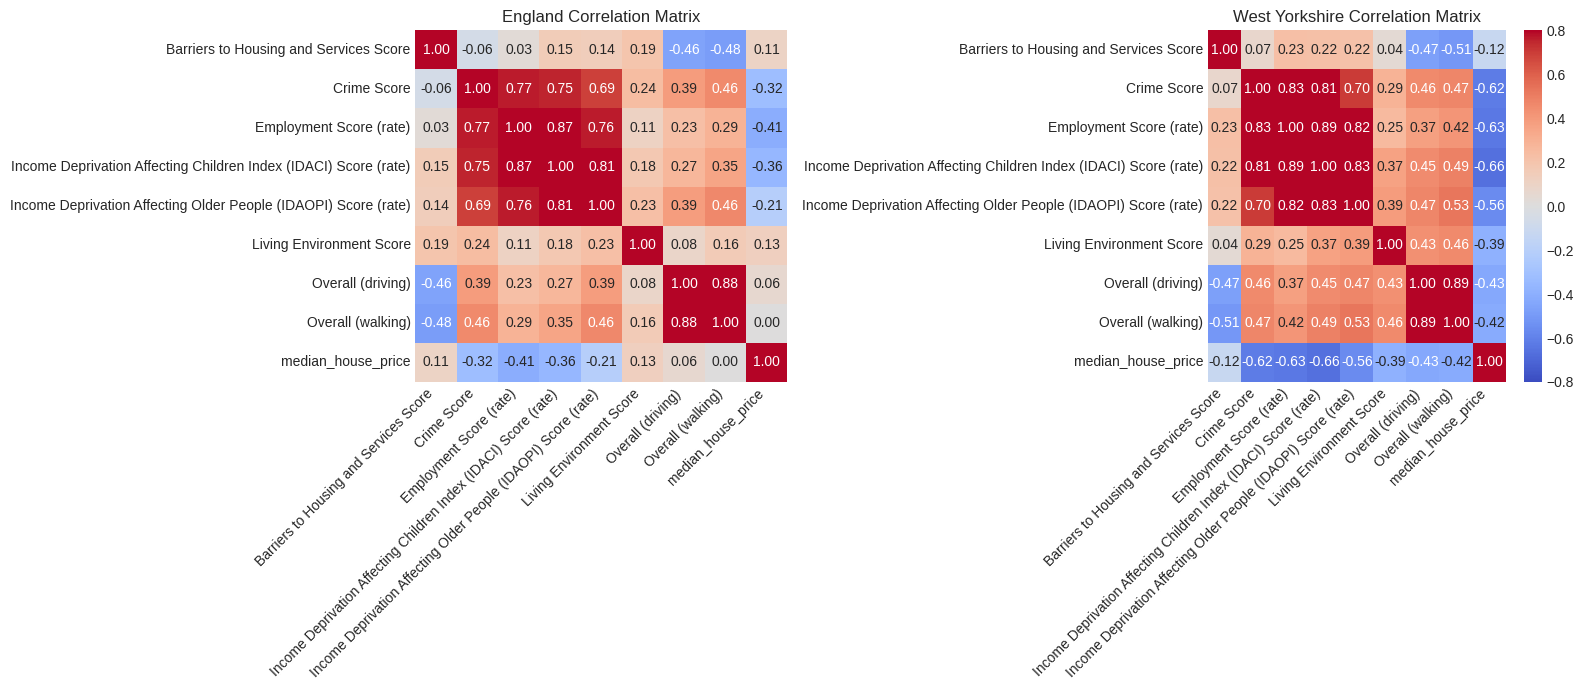

In [19]:
# Figure 2: Side-by-Side Correlation Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

corr_cols = common_features + ['median_house_price']
corr_eng = df_eng[corr_cols].corr()
corr_wy = df_wy[corr_cols].corr()

sns.heatmap(corr_eng, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0], cbar=False, vmin=-0.8, vmax=0.8)
axes[0].set_title('England Correlation Matrix')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

sns.heatmap(corr_wy, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1], cbar=True, vmin=-0.8, vmax=0.8)
axes[1].set_title('West Yorkshire Correlation Matrix')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('output_figures/fig2_correlation_heatmaps.png', dpi=300)
plt.show()


## Step 4: Machine Learning Model Development & Evaluation

### Modeling Methodology:
- **Train-Test Split:** 80% Training set, 20% Testing set using a fixed `random_state=42`.

In [20]:
def train_and_evaluate(df, features, target_col='median_house_price', dataset_name="England"):
    X = df[features]
    y = df[target_col]
    y_log = np.log(y)

    X_train, X_test, y_train, y_test, y_train_raw, y_test_raw = train_test_split(
        X, y_log, y, test_size=0.2, random_state=42
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    models = {
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(n_estimators=150, max_depth=12, random_state=42, n_jobs=1),
        'XGBoost': XGBRegressor(n_estimators=150, max_depth=6, learning_rate=0.08, random_state=42, n_jobs=1)
    }

    results, preds, importances = {}, {}, {}

    for name, model in models.items():
        if name == 'Linear Regression':
            model.fit(X_train_scaled, y_train)
            pred_log = model.predict(X_test_scaled)
            importances[name] = pd.Series(model.coef_, index=features)
        else:
            model.fit(X_train, y_train)
            pred_log = model.predict(X_test)
            importances[name] = pd.Series(model.feature_importances_, index=features)

        pred_raw = np.exp(pred_log)
        mae = mean_absolute_error(y_test_raw, pred_raw)
        rmse = np.sqrt(mean_squared_error(y_test_raw, pred_raw))
        r2 = r2_score(y_test_raw, pred_raw)

        results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
        preds[name] = pred_raw

    return results, preds, importances, y_test_raw

results_eng, preds_eng, imp_eng, y_test_eng = train_and_evaluate(df_eng, common_features, dataset_name="England")
results_wy, preds_wy, imp_wy, y_test_wy = train_and_evaluate(df_wy, common_features, dataset_name="West Yorkshire")


In [21]:
# Format Summary Performance Table
summary_data = []
for name in results_eng:
    summary_data.append({
        'Dataset': 'England', 'Model': name,
        'MAE (£)': results_eng[name]['MAE'],
        'RMSE (£)': results_eng[name]['RMSE'],
        'R2 Score': results_eng[name]['R2']
    })
for name in results_wy:
    summary_data.append({
        'Dataset': 'West Yorkshire', 'Model': name,
        'MAE (£)': results_wy[name]['MAE'],
        'RMSE (£)': results_wy[name]['RMSE'],
        'R2 Score': results_wy[name]['R2']
    })

df_summary = pd.DataFrame(summary_data)
df_summary.to_csv('results/model_performance_summary.csv', index=False)

print("=== Model Performance Summary Table ===")
display(df_summary)


=== Model Performance Summary Table ===


,Dataset,Model,MAE (£),RMSE (£),R2 Score
0,England,Linear Regression,112711.576220,190735.176064,0.280911
1,England,Random Forest,94588.717470,158270.910687,0.504865
2,England,XGBoost,94299.515313,158210.363010,0.505244
3,West Yorkshire,Linear Regression,40691.027302,72973.859599,0.539542
4,West Yorkshire,Random Forest,37832.110109,64576.491809,0.639418
5,West Yorkshire,XGBoost,38096.830150,67076.425003,0.610959


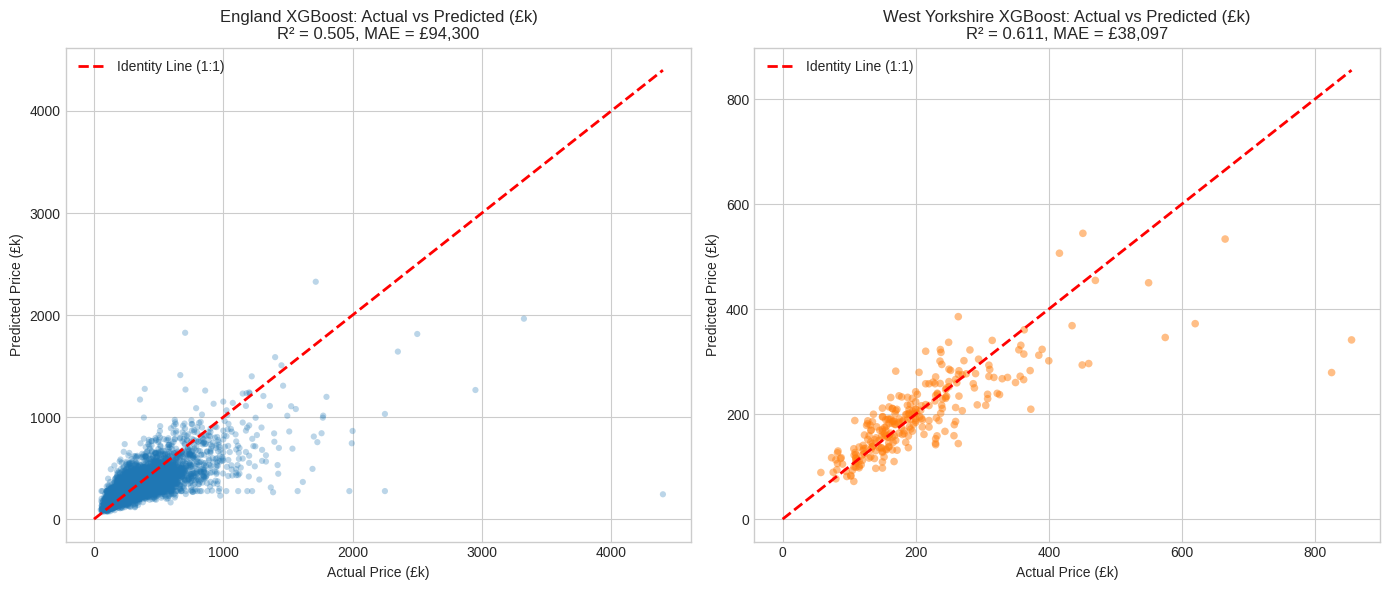

In [22]:
# Figure 3: Actual vs Predicted Scatter Plots (XGBoost)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test_eng / 1e3, preds_eng['XGBoost'] / 1e3, alpha=0.3, color='#1f77b4', edgecolors='none', s=20)
max_eng = max(y_test_eng.max(), preds_eng['XGBoost'].max()) / 1e3
axes[0].plot([0, max_eng], [0, max_eng], 'r--', lw=2, label='Identity Line (1:1)')
axes[0].set_title(f"England XGBoost: Actual vs Predicted (£k)\nR² = {results_eng['XGBoost']['R2']:.3f}, MAE = £{results_eng['XGBoost']['MAE']:,.0f}")
axes[0].set_xlabel('Actual Price (£k)')
axes[0].set_ylabel('Predicted Price (£k)')
axes[0].legend()

axes[1].scatter(y_test_wy / 1e3, preds_wy['XGBoost'] / 1e3, alpha=0.5, color='#ff7f0e', edgecolors='none', s=30)
max_wy = max(y_test_wy.max(), preds_wy['XGBoost'].max()) / 1e3
axes[1].plot([0, max_wy], [0, max_wy], 'r--', lw=2, label='Identity Line (1:1)')
axes[1].set_title(f"West Yorkshire XGBoost: Actual vs Predicted (£k)\nR² = {results_wy['XGBoost']['R2']:.3f}, MAE = £{results_wy['XGBoost']['MAE']:,.0f}")
axes[1].set_xlabel('Actual Price (£k)')
axes[1].set_ylabel('Predicted Price (£k)')
axes[1].legend()

plt.tight_layout()
plt.savefig('output_figures/fig3_actual_vs_predicted.png', dpi=300)
plt.show()


## Step 5: Feature Importance & Coefficient Analysis

To determine which explanatory factors are the strongest predictors of LSOA house prices.


In [23]:
df_imp_eng = pd.DataFrame(imp_eng)
df_imp_wy = pd.DataFrame(imp_wy)

df_imp_eng.to_csv('results/feature_importance_england.csv')
df_imp_wy.to_csv('results/feature_importance_wy.csv')

print("Feature Importances: England ")
display(df_imp_eng)

print("\n Feature Importances: West Yorkshire ")
display(df_imp_wy)


Feature Importances: England 


,Linear Regression,Random Forest,XGBoost
Barriers to Housing and Services Score,0.202341,0.097175,0.087140
Crime Score,-0.094890,0.037860,0.040933
Employment Score (rate),-0.226828,0.511291,0.518920
Income Deprivation Affecting Children Index (IDACI) Score (rate),-0.154326,0.047002,0.056522
Income Deprivation Affecting Older People (IDAOPI) Score (rate),0.075925,0.036364,0.033704
Living Environment Score,0.014268,0.064797,0.057339
Overall (driving),0.104833,0.153245,0.154619
Overall (walking),0.088671,0.052266,0.050822



 Feature Importances: West Yorkshire 


,Linear Regression,Random Forest,XGBoost
Barriers to Housing and Services Score,-0.096229,0.046361,0.030730
Crime Score,-0.028477,0.040727,0.027184
Employment Score (rate),-0.167465,0.158536,0.138105
Income Deprivation Affecting Children Index (IDACI) Score (rate),-0.066031,0.509633,0.559617
Income Deprivation Affecting Older People (IDAOPI) Score (rate),0.053955,0.056885,0.050575
Living Environment Score,-0.088166,0.121290,0.113211
Overall (driving),-0.071381,0.035680,0.038424
Overall (walking),-0.043384,0.030890,0.042155


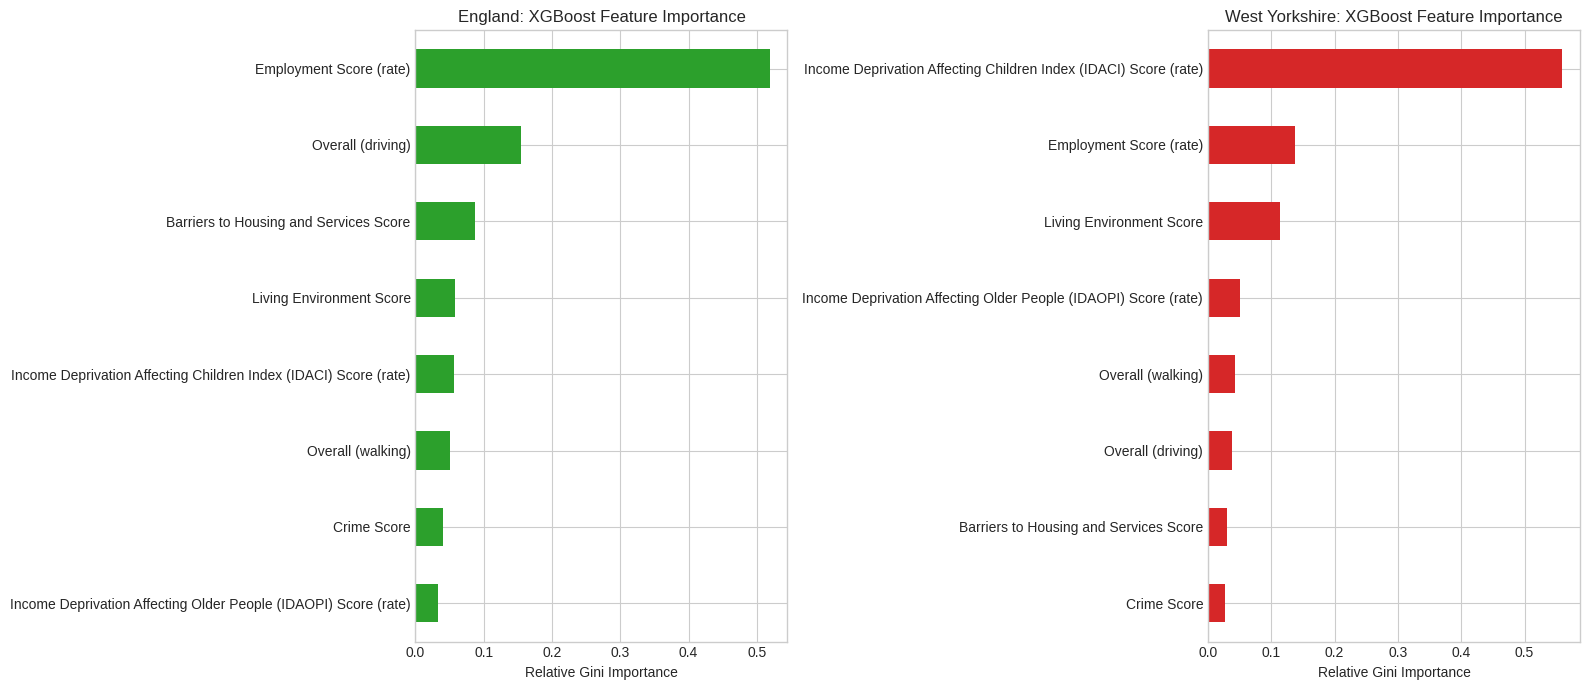

In [24]:
# Figure 4: Side-by-Side Feature Importance Bar Charts (XGBoost)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

imp_eng['XGBoost'].sort_values(ascending=True).plot(kind='barh', ax=axes[0], color='#2ca02c')
axes[0].set_title('England: XGBoost Feature Importance')
axes[0].set_xlabel('Relative Gini Importance')

imp_wy['XGBoost'].sort_values(ascending=True).plot(kind='barh', ax=axes[1], color='#d62728')
axes[1].set_title('West Yorkshire: XGBoost Feature Importance')
axes[1].set_xlabel('Relative Gini Importance')

plt.tight_layout()
plt.savefig('output_figures/fig4_feature_importances.png', dpi=300)
plt.show()


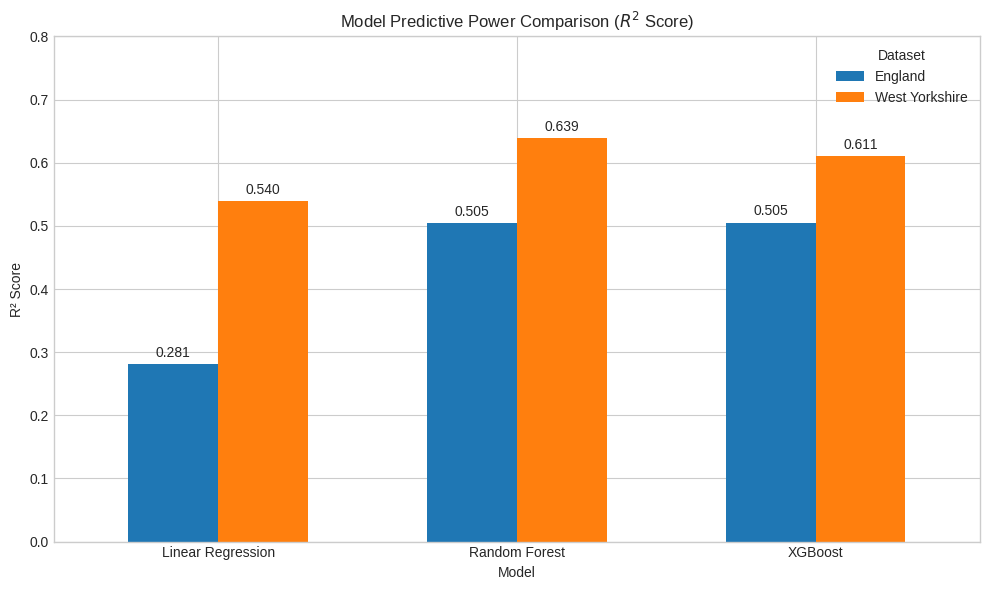

In [25]:
# Figure 5: Model Performance Comparison Bar Chart ($R^2$)
fig, ax = plt.subplots(figsize=(10, 6))
df_summary.pivot(index='Model', columns='Dataset', values='R2 Score').plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e'], width=0.6)
ax.set_title('Model Predictive Power Comparison ($R^2$ Score)')
ax.set_ylabel('R² Score')
ax.set_ylim(0, 0.8)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 3), textcoords='offset points')

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('output_figures/fig5_model_comparison_r2.png', dpi=300)
plt.show()
